# 2.1 二値変数 (Binary Variables)
本ノートブックでは、二値（バイナリ）確率変数のモデル化である**ベルヌーイ分布 (Bernoulli distribution)**、**二項分布 (Binomial distribution)**、そしてベイズ推論のための共役事前分布である**ベータ分布 (Beta distribution)** について理論と実装の両面から詳しく学びます。

### 本ノートブックの構成:
1. **ベルヌーイ分布と最尤推定 (MLE)**: ゼロ頻度問題と過学習の数理
2. **二項分布 (Binomial distribution)**: 試行回数 $N$ と成功回数 $m$ の分布
3. **ベータ分布 (Beta distribution)**: 共役事前分布とハイパーパラメータの有効観測数解釈
4. **逐次ベイズ更新 (Sequential Learning)**: データの逐次到着に伴う事後分布の進化
5. **事後予測分布とラプラスの継起則 (Laplace's Rule of Succession)**

## 2.1.1 ベルヌーイ分布と最尤推定 (MLE)

1回の試行で2つの結果（表/裏、成功/失敗、0/1）のいずれかをとる確率変数 $x \in \{0, 1\}$ を考えます。
パラメータ $\mu \in [0, 1]$ を $x=1$ となる確率とすると、$p(x=1|\mu) = \mu$, $p(x=0|\mu) = 1 - \mu$ です。
これを1つの数式で表現したものが**ベルヌーイ分布 (Bernoulli distribution)** です。

$$ \mathrm{Bern}(x | \mu) = \mu^x (1 - \mu)^{1 - x} $$

### 期待値と分散
- 期待値: $\mathbb{E}[x] = 1 \cdot \mu + 0 \cdot (1 - \mu) = \mu$
- 分散: $\mathrm{var}[x] = \mathbb{E}[x^2] - \mathbb{E}[x]^2 = \mu - \mu^2 = \mu(1 - \mu)$

### 最尤推定 (Maximum Likelihood Estimation)
観測データセット $\mathcal{D} = \{x_1, x_2, \dots, x_N\}$ が独立同分布 (i.i.d.) で得られたと仮定すると、最尤推定量 $\mu_{\mathrm{ML}}$ は以下のように求まります。

$$ \mu_{\mathrm{ML}} = \frac{m}{N} $$
ここで $m = \sum_{n=1}^N x_n$ は表が出た回数です。

データ数が少ない場合、例えばコインを3回投げて3回とも表が出た場合（$N=3, m=3$）、最尤推定は $\mu_{\mathrm{ML}} = 1.0$ となり、次に裏が出る確率を厳密に 0 と予測してしまいます（過学習・ゼロ頻度問題）。

Plot saved to: result/fig2_laplace_smoothing.png


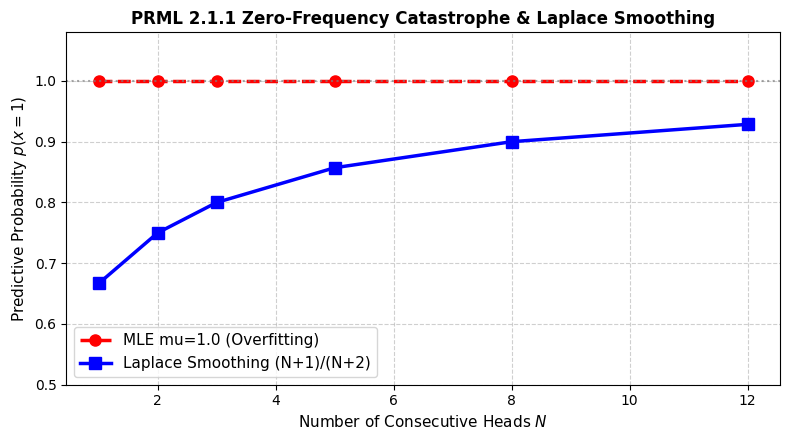

In [1]:
# ゼロ頻度問題とラプラスの継起則 (Laplace's Rule of Succession)
import sys, os
sys.path.append(os.path.abspath('../'))
os.makedirs("result", exist_ok=True)
from common.plot_utils import save_plot, setup_style
setup_style()

import numpy as np
import matplotlib.pyplot as plt

small_N = np.array([1, 2, 3, 5, 8, 12])
all_heads_mle = np.ones_like(small_N, dtype=float)
all_heads_laplace = (small_N + 1.0) / (small_N + 2.0)

fig = plt.figure(figsize=(8, 4.5))
plt.plot(small_N, all_heads_mle, 'ro--', lw=2.5, markersize=8, label='MLE mu=1.0 (Overfitting)')
plt.plot(small_N, all_heads_laplace, 'bs-', lw=2.5, markersize=8, label='Laplace Smoothing (N+1)/(N+2)')
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.7)
plt.title('PRML 2.1.1 Zero-Frequency Catastrophe & Laplace Smoothing', fontsize=12, fontweight='bold')
plt.xlabel('Number of Consecutive Heads $N$', fontsize=11)
plt.ylabel('Predictive Probability $p(x=1)$', fontsize=11)
plt.ylim(0.5, 1.08)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
save_plot(fig, "result", "fig2_laplace_smoothing.png")
plt.show()

## 2.1.2 二項分布 (Binomial Distribution)

サイズ $N$ のデータセットにおいて、$x=1$ となる回数 $m$ の確率分布は**二項分布**で与えられます。

$$ \mathrm{Bin}(m | N, \mu) = \binom{N}{m} \mu^m (1 - \mu)^{N - m} $$

平均と分散:
$$ \mathbb{E}[m] = N\mu, \quad \mathrm{var}[m] = N\mu(1 - \mu) $$

## 2.1.3 ベータ分布 (The Beta Distribution)

二項尤度に対する共役事前分布として**ベータ分布**を導入します。

$$ \mathrm{Beta}(\mu | a, b) = \frac{\Gamma(a + b)}{\Gamma(a)\Gamma(b)} \mu^{a - 1} (1 - \mu)^{b - 1} $$

- 期待値: $\mathbb{E}[\mu] = \frac{a}{a + b}$
- 分散: $\mathrm{var}[\mu] = \frac{ab}{(a + b)^2 (a + b + 1)}$
- 最頻値 ($a, b > 1$): $\mu^* = \frac{a - 1}{a + b - 2}$

### ベイズ更新
表が $m$ 回、裏が $l = N - m$ 回観測されたときの事後分布:
$$ p(\mu | m, l, a, b) = \mathrm{Beta}(\mu | a + m, b + l) $$
ハイパーパラメータ $a, b$ は**有効観測数**（事前擬似観測カウント）として機能します。

Plot saved to: result/fig2_2_beta_priors.png


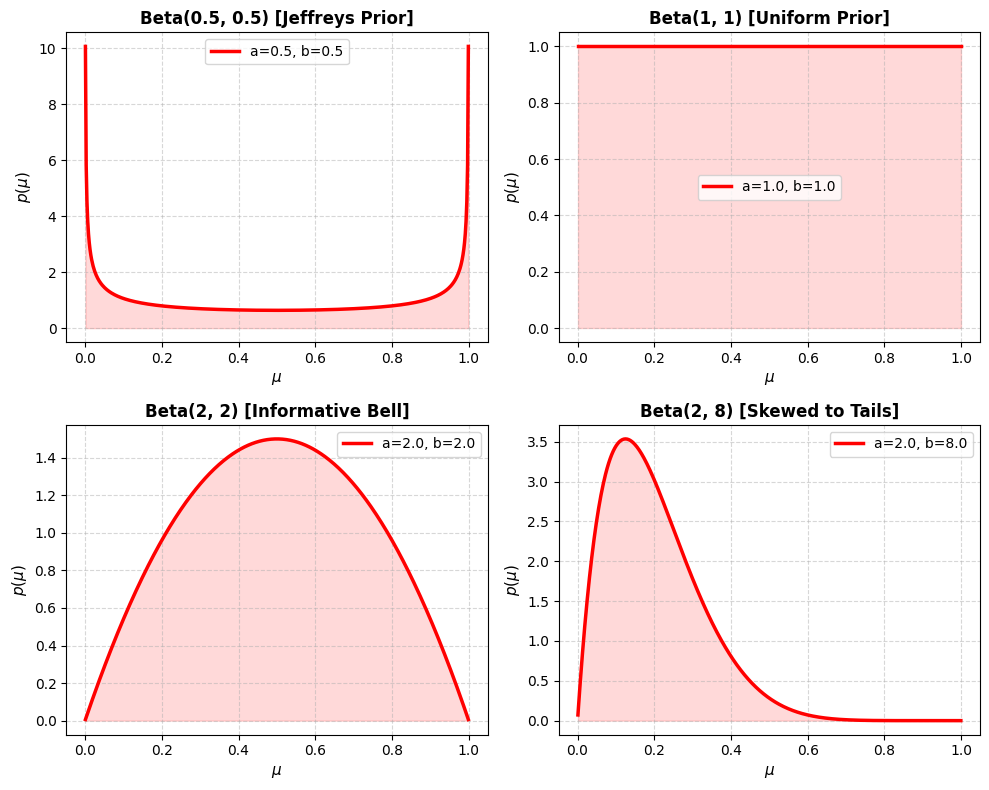

In [2]:
# 様々なハイパーパラメータに対するベータ分布の形状 (PRML Fig 2.2)
from prml.distributions import BetaDistribution

mu_vals = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
params = [(0.5, 0.5), (1.0, 1.0), (2.0, 2.0), (2.0, 8.0)]
titles = ["Beta(0.5, 0.5) [Jeffreys Prior]", "Beta(1, 1) [Uniform Prior]",
          "Beta(2, 2) [Informative Bell]", "Beta(2, 8) [Skewed to Tails]"]

for ax, (a, b), title in zip(axes.ravel(), params, titles):
    beta = BetaDistribution(a=a, b=b)
    pdf = beta.pdf(mu_vals)
    ax.plot(mu_vals, pdf, 'r-', lw=2.5, label=f'a={a}, b={b}')
    ax.fill_between(mu_vals, 0, pdf, color='red', alpha=0.15)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$\mu$', fontsize=11)
    ax.set_ylabel(r'$p(\mu)$', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
save_plot(fig, "result", "fig2_2_beta_priors.png")
plt.show()

## 2.1.4 逐次ベイズ更新 (Sequential Learning) と MLE 収束比較

真のパラメータ $\mu^* = 0.7$ からのコイン投げ観測に伴い、事後ベータ分布が真値に集中していく過程を検証します。

Plot saved to: result/fig2_3_bayesian_sequential_learning.png


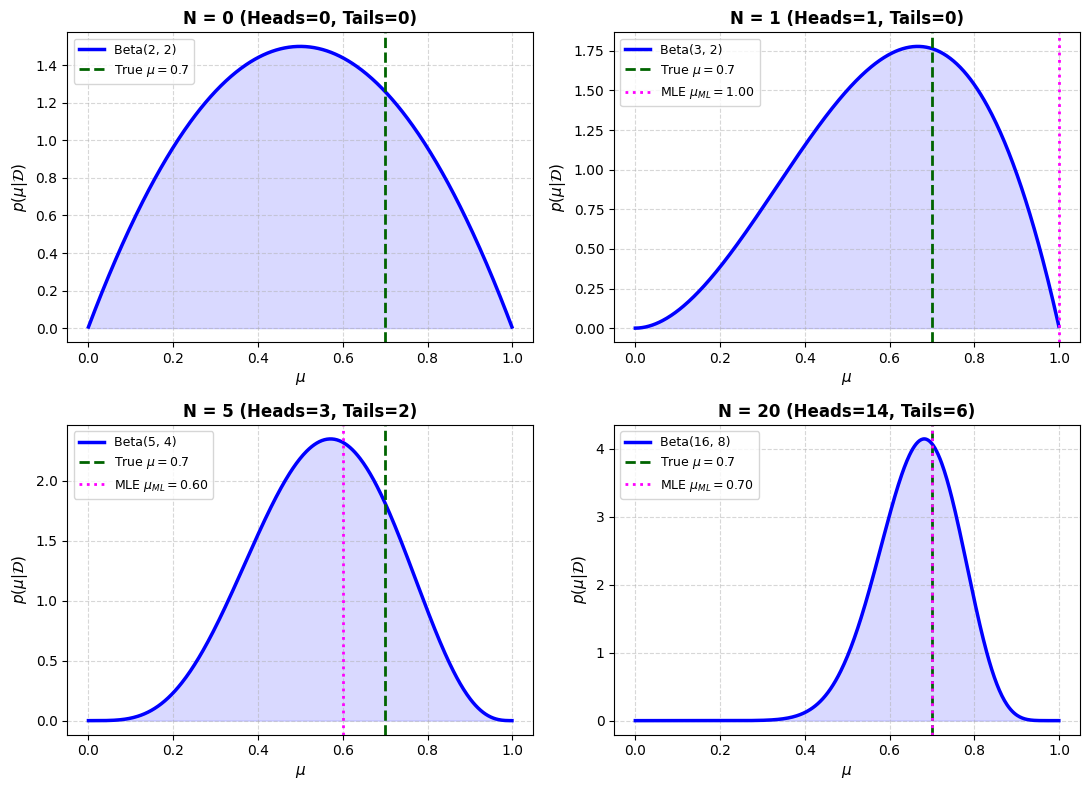

In [3]:
# 逐次ベイズ更新のシミュレーション (PRML Fig 2.3)
np.random.seed(42)
true_mu = 0.7
flips = np.random.binomial(1, true_mu, size=30)
prior = BetaDistribution(a=2.0, b=2.0)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
checkpoints = [0, 1, 5, 20]

for ax, n in zip(axes.ravel(), checkpoints):
    m = int(np.sum(flips[:n])) if n > 0 else 0
    l = n - m
    post = prior.bayesian_update(n_heads=m, n_tails=l)
    pdf = post.pdf(mu_vals)
    
    ax.plot(mu_vals, pdf, 'b-', lw=2.5, label=f'Beta({post.a:.0f}, {post.b:.0f})')
    ax.fill_between(mu_vals, 0, pdf, color='blue', alpha=0.15)
    ax.axvline(true_mu, color='darkgreen', linestyle='--', lw=2, label=f'True $\mu={true_mu}$')
    if n > 0:
        ax.axvline(m / n, color='magenta', linestyle=':', lw=2, label=f'MLE $\mu_{{ML}}={m/n:.2f}$')
    ax.set_title(f'N = {n} (Heads={m}, Tails={l})', fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$\mu$', fontsize=11)
    ax.set_ylabel(r'$p(\mu|\mathcal{D})$', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
save_plot(fig, "result", "fig2_3_bayesian_sequential_learning.png")
plt.show()

Plot saved to: result/fig2_1_mle_vs_bayes_convergence.png


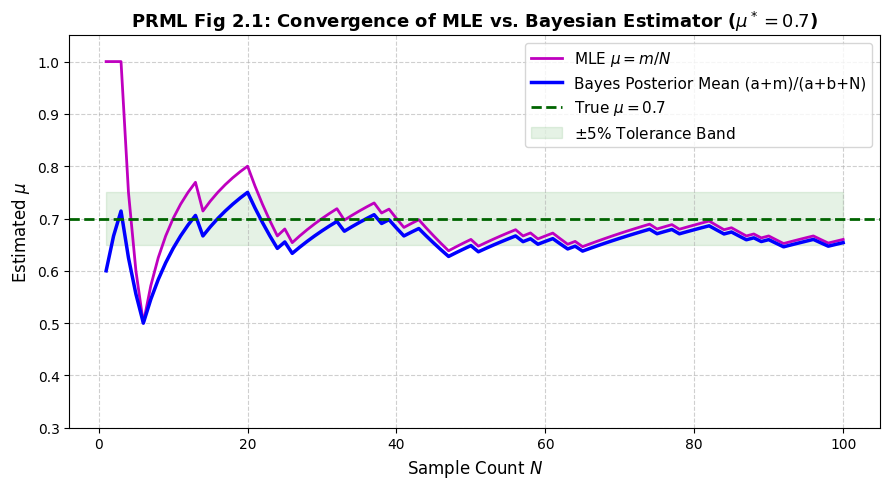

In [4]:
# MLE とベイズ推論のサンプルサイズ N に対する収束挙動 (PRML Fig 2.1)
N_steps = np.arange(1, 101)
flips_100 = np.random.binomial(1, true_mu, size=100)
heads_cum = np.cumsum(flips_100)
mle_estimates = heads_cum / N_steps
bayes_estimates = (2.0 + heads_cum) / (2.0 + 2.0 + N_steps)

fig = plt.figure(figsize=(9, 5))
plt.plot(N_steps, mle_estimates, 'm-', lw=2, label=r'MLE $\mu = m/N$')
plt.plot(N_steps, bayes_estimates, 'b-', lw=2.5, label='Bayes Posterior Mean (a+m)/(a+b+N)')
plt.axhline(true_mu, color='darkgreen', linestyle='--', lw=2, label=f'True $\mu = {true_mu}$')
plt.fill_between(N_steps, true_mu - 0.05, true_mu + 0.05, color='green', alpha=0.1, label=r'$\pm 5\%$ Tolerance Band')
plt.title(r'PRML Fig 2.1: Convergence of MLE vs. Bayesian Estimator ($\mu^*=0.7$)', fontsize=13, fontweight='bold')
plt.xlabel('Sample Count $N$', fontsize=12)
plt.ylabel(r'Estimated $\mu$', fontsize=12)
plt.ylim(0.3, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
save_plot(fig, "result", "fig2_1_mle_vs_bayes_convergence.png")
plt.show()

## まとめ
1. 最尤推定量 $\mu_{\mathrm{ML}} = m/N$ はデータ数が少ない場合に深刻な過学習（ゼロ頻度問題）を引き起こす。
2. 共役事前分布としてベータ分布を用いることで、事後分布が閉じた形で得られ、解析的な逐次更新が可能になる。
3. 事前分布のパラメータ $a, b$ は有効観測数として機能し、データが少ない領域で自然な正則化（ラプラス平滑化など）を提供する。
4. サンプル数 $N \to \infty$ において、ベイズ事後平均は最尤推定量 $\mu_{\mathrm{ML}}$ に漸近し、客観的な真のパラメータに収束する。